# Préparation

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score, ConfusionMatrixDisplay
from pathlib import Path

In [43]:
from pathlib import Path

In [44]:
COLORS = {'primary':'#E91E8C','secondary':'#7B2FBE','accent':'#00D4AA','dark':'#1A1A2E'}
PALETTE= ['#E91E8C','#7B2FBE','#00D4AA','#FF6B35','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
                     'axes.grid':True,'grid.alpha':0.25,'font.size':11,
                     'axes.spines.top':False,'axes.spines.right':False})

BASE      = Path('..')
DATA_PROC = BASE / 'data' / 'processed'
MODELS    = BASE / 'models'
for p in [DATA_PROC, MODELS, BASE/'data'/'raw']: p.mkdir(parents=True, exist_ok=True)

# CLASSIFICATION

In [53]:
df = pd.read_csv("../data/processed/gdelt_benin_clean.csv")

features = [
    'GoldsteinNorm',
    'ToneNorm',
    'NumMentions',
    'NumArticles',
    'MediaWeight'
]

X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## PCA

In [6]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print(pca.explained_variance_ratio_)

[0.37934256 0.31115678]


## K-Means

k=2: silhouette=0.6770
k=3: silhouette=0.5913
k=4: silhouette=0.5460
k=5: silhouette=0.5254
k=6: silhouette=0.4800
k=7: silhouette=0.4633
k=8: silhouette=0.4357
k=9: silhouette=0.4297

✅ k optimal = 2


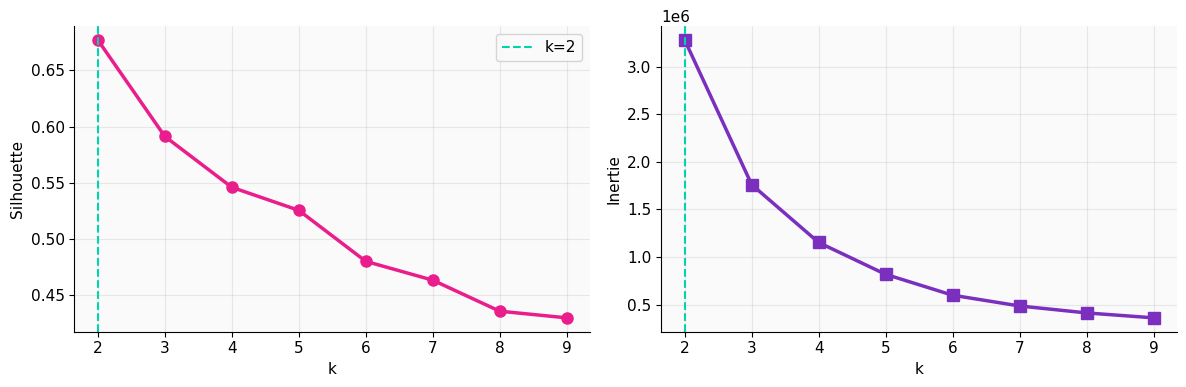

In [57]:
# K-Means optimal
sil,inert={},{}
for k in range(2,10):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    lbl=km.fit_predict(X)
    sil[k]=silhouette_score(X,lbl,sample_size=2000)
    inert[k]=km.inertia_
    print(f'k={k}: silhouette={sil[k]:.4f}')
best_k=max(sil,key=sil.get)
print(f'\n✅ k optimal = {best_k}')

fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(list(sil.keys()),list(sil.values()),'o-',color=COLORS['primary'],lw=2.5,ms=8)
axes[0].axvline(best_k,ls='--',color=COLORS['accent'],label=f'k={best_k}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette'); axes[0].legend()
axes[1].plot(list(inert.keys()),list(inert.values()),'s-',color=COLORS['secondary'],lw=2.5,ms=8)
axes[1].axvline(best_k,ls='--',color=COLORS['accent'])
axes[1].set_xlabel('k'); axes[1].set_ylabel('Inertie')
plt.tight_layout(); plt.show()

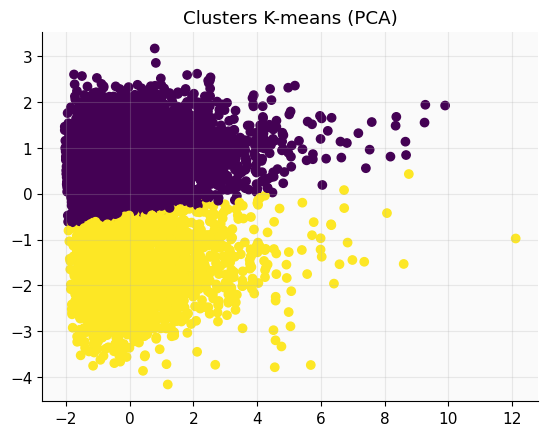

In [61]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = clusters

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Clusters K-means (PCA)")
plt.show()

In [70]:
df.columns

Index(['SQLDATE', 'date', 'Actor1Name', 'Actor1CountryCode', 'EventCode',
       'EventLabel', 'QuadClass', 'GoldsteinScale', 'NumMentions',
       'NumArticles', 'AvgTone', 'ActionGeo_FullName', 'ActionGeo_Lat',
       'ActionGeo_Long', 'SourceDomain', 'QuadLabel', 'IsConflict',
       'IsNegative', 'MediaWeight', 'IsNorthBenin', 'ZoneBenin',
       'DepartementBenin', 'SourceRegion', 'GoldsteinNorm', 'ToneNorm',
       'month', 'ToneCategory', 'GoldsteinBin', 'cluster_kmeans',
       'cluster_dbscan', 'PCA1', 'PCA2'],
      dtype='object')

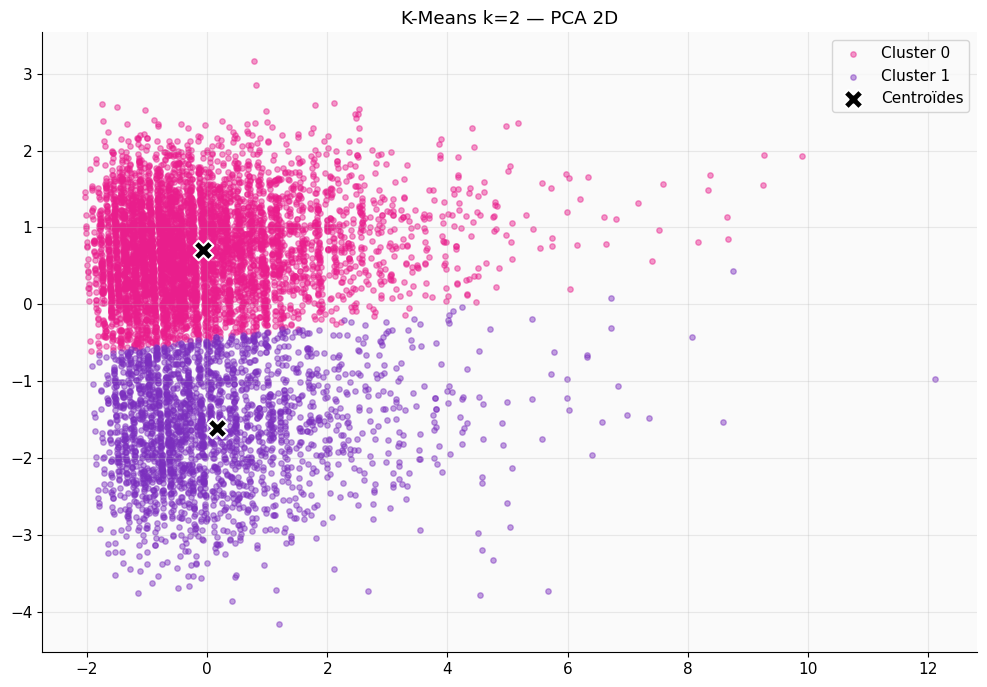

                Événements  Tone_moyen  Goldstein_moy             Thème_top Ville_top Conflits_pct
cluster_kmeans                                                                                    
0                     5552        1.87           2.06  Declaration publique   Cotonou           3%
1                     2448       -4.22          -3.55      Rejet/opposition   Cotonou          91%


In [71]:
df['PCA1'],df['PCA2']=X_pca[:,0],X_pca[:,1]

fig,ax=plt.subplots(figsize=(10,7))
for i,c in enumerate(sorted(df['cluster_kmeans'].unique())):
    mask=df['cluster_kmeans']==c
    ax.scatter(df.loc[mask,'PCA1'],df.loc[mask,'PCA2'],s=15,alpha=.45,color=PALETTE[i],label=f'Cluster {c}')
centers_2d=pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_2d[:,0],centers_2d[:,1],s=200,marker='X',color='black',edgecolors='white',lw=1.5,zorder=5,label='Centroïdes')
ax.set_title(f'K-Means k={2} — PCA 2D'); ax.legend()
plt.tight_layout()
# plt.savefig(DATA_PROC/'viz_clusters.png',dpi=150,bbox_inches='tight')
plt.show()

profile=df.groupby('cluster_kmeans').agg(
    Événements=('EventCode','count'),Tone_moyen=('AvgTone','mean'),
    Goldstein_moy=('GoldsteinScale','mean'),Thème_top=('EventLabel',lambda x:x.mode()[0]),
    Ville_top=('ActionGeo_FullName',lambda x:x.mode()[0]),
    Conflits_pct=('IsConflict',lambda x:f'{x.mean()*100:.0f}%')).round(2)
print(profile.to_string())

## DBSCAN

In [62]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

df['cluster_dbscan'] = db_clusters

In [63]:
df.groupby('cluster_kmeans')[features].mean()

,GoldsteinNorm,ToneNorm,NumMentions,NumArticles,MediaWeight
cluster_kmeans,,,,,
0,0.603206,0.546824,7.926693,3.966138,31.294669
1,0.322609,0.394390,8.068627,4.136438,33.278595


## PERL

In [64]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [65]:
# VIZ 1 — Timeline
df_wk = df.groupby(df['date'].dt.to_period('W')).agg(EventCount=('AvgTone','count'), Golde_moyen=('GoldsteinScale','mean'), AvgTone=('AvgTone','mean')).reset_index()

In [32]:
import ruptures as rpt
import numpy as np

# Signal = série mensuelle du ton moyen
signal = df_wk['tone'].values

# Algorithme PELT avec kernel RBF
model = rpt.Pelt(model='rbf').fit(signal)
breakpoints = model.predict(pen=10)  # pen = sensibilité, à calibrer

# Résultat : liste des indices de rupture
# ex : [8, 13] = rupture à la semaine 8 et à la fin
print(f'Ruptures détectées aux semaines : {breakpoints}')


Ruptures détectées aux semaines : [53]


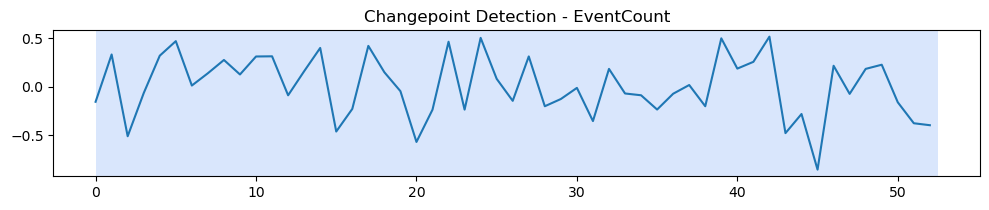

In [ ]:
rpt.display(signal, breakpoints)
plt.title("Changepoint Detection - EventCount")
plt.show()

EventCount -> ruptures: [53]


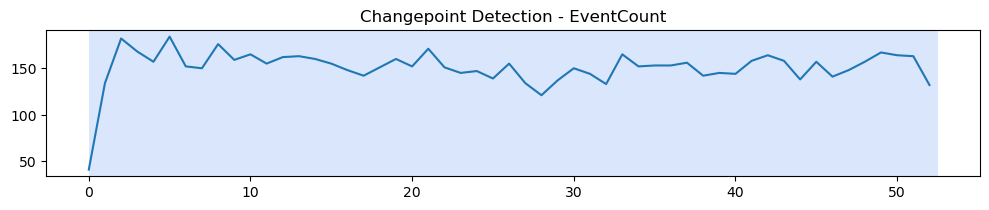

AvgTone -> ruptures: [53]


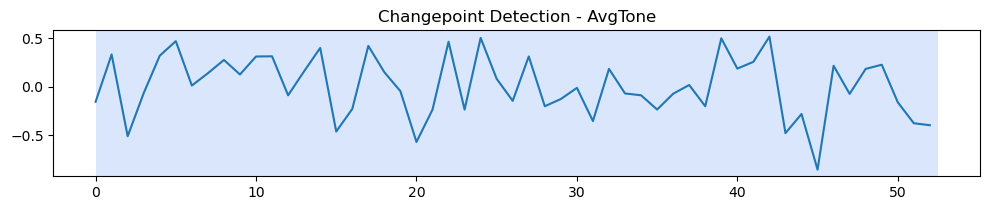

Golde_moyen -> ruptures: [15, 53]


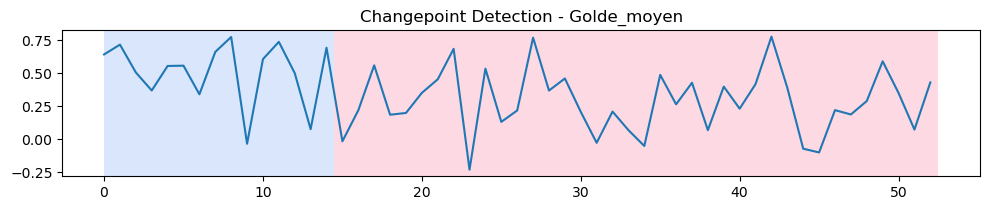

In [41]:
for col in ['EventCount', 'AvgTone', 'Golde_moyen']:
    signal = df_wk[col].values
    
    model = rpt.Pelt(model="rbf").fit(signal)
    bkps = model.predict(pen=2)
    
    print(f"{col} -> ruptures:", bkps)
    rpt.display(signal, bkps)
    plt.title(f"Changepoint Detection - {col}")
    plt.show()

# PREDICTION

In [11]:
y = df['IsConflict']

In [49]:
features = [
    'GoldsteinNorm',
    'ToneNorm',
    'NumMentions',
    'NumArticles',
    'MediaWeight',
    'IsNorthBenin'
]

X = df[features].sum()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## RANDOM FOREST

              precision    recall  f1-score   support

 Coopération       0.96      0.97      0.97      1123
     Conflit       0.93      0.91      0.92       477

    accuracy                           0.95      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.95      0.95      0.95      1600



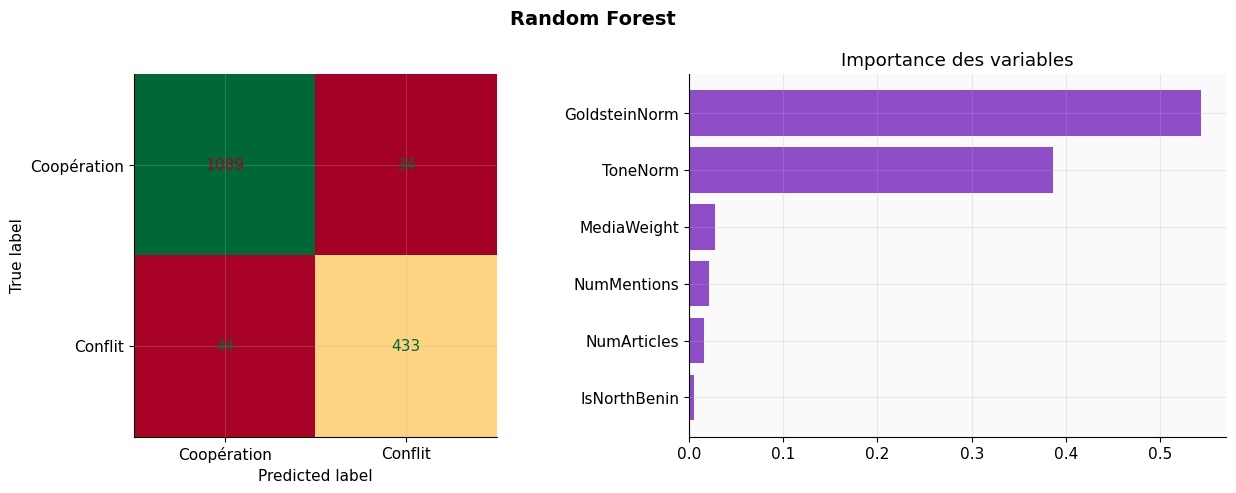

In [46]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# print(classification_report(y_test, y_pred))


report=classification_report(y_test,y_pred,target_names=['Coopération','Conflit'],output_dict=True)
cm=confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred,target_names=['Coopération','Conflit']))

fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle('Random Forest',fontsize=14,fontweight='bold')
ConfusionMatrixDisplay(cm,display_labels=['Coopération','Conflit']).plot(ax=axes[0],cmap='RdYlGn',colorbar=False)
imp=pd.Series(model.feature_importances_,index=features).sort_values()
axes[1].barh(imp.index,imp.values,color=COLORS['secondary'],alpha=.85)
axes[1].set_title('Importance des variables')
plt.tight_layout()
# plt.savefig(DATA_PROC/'viz_rf.png',dpi=150,bbox_inches='tight')
plt.show()

## XGBOOST

c:\Users\TSS\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:10:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

 Coopération       0.95      0.97      0.96      1123
     Conflit       0.93      0.89      0.91       477

    accuracy                           0.95      1600
   macro avg       0.94      0.93      0.94      1600
weighted avg       0.95      0.95      0.95      1600



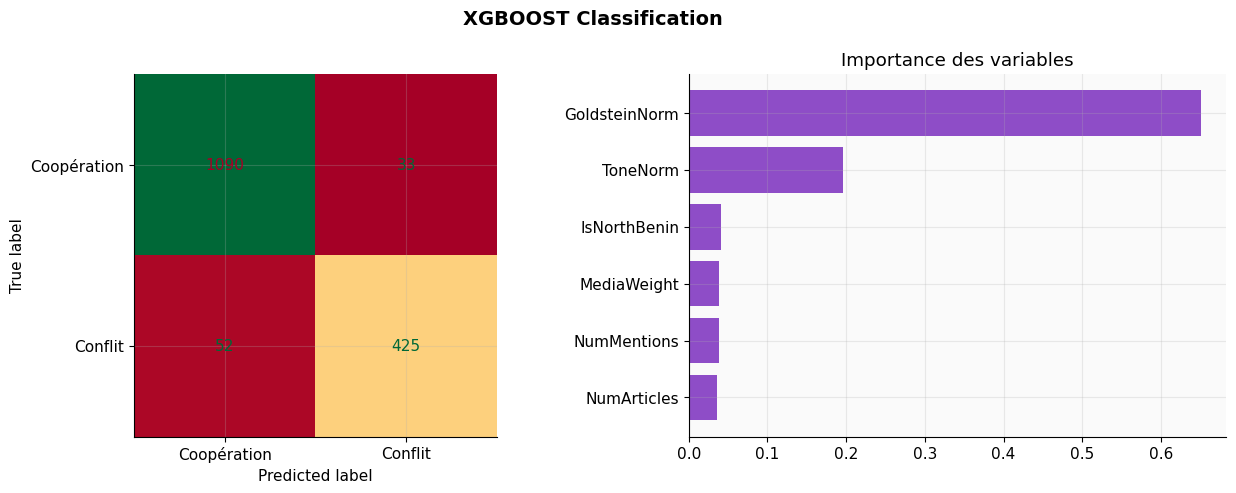

In [51]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# print(classification_report(y_test, y_pred))

report=classification_report(y_test,y_pred,target_names=['Coopération','Conflit'],output_dict=True)
cm=confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred,target_names=['Coopération','Conflit']))

fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle('XGBOOST Classification',fontsize=14,fontweight='bold')
ConfusionMatrixDisplay(cm,display_labels=['Coopération','Conflit']).plot(ax=axes[0],cmap='RdYlGn',colorbar=False)
imp=pd.Series(model.feature_importances_,index=features).sort_values()
axes[1].barh(imp.index,imp.values,color=COLORS['secondary'],alpha=.85)
axes[1].set_title('Importance des variables')
plt.tight_layout()
# plt.savefig(DATA_PROC/'viz_rf.png',dpi=150,bbox_inches='tight')
plt.show()

In [17]:
df['proba_conflict'] = model.predict_proba(X)[:,1]